# BLAS Calls → GPU Kernel Sequences → Power

For each CPU-side BLAS call (`rocblas_dgemm`, `rocblas_dtrsm`, `rocblas_dgemv`, `rocblas_dtrsv`, …)
we identify the **exact sequence of GPU kernels** it launched and the **power** observed
during that window.

- **CPU data**: MPI rank master-thread callgraphs — we keep only the real BLAS entry points
  (ignoring `rocBLASCheck`, `hipLaunchKernel`, `hipDeviceSynchronize`, and other HIP runtime noise).
- **GPU data**: HIP context callgraphs — these contain the actual kernels
  (`Cijk_*` GEMM variants, `rocblas_trtri_*`, `rocblas_trsm_*`, `rocblas_copy_matrix_trsm`,
  `dlaswp00N`, `dlatcpy`, …).
- **Power**: instantaneous power derived from per-device energy counters.

Set `TRACE_PATH` below. Only `hpl-captured-params-HIP` contains HIP context kernels.

In [35]:
# -- Setup --
import os, re, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from collections import Counter

plt.rcParams.update({
    'figure.dpi': 160, 'savefig.dpi': 300,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'serif'],
    'font.size': 9.5, 'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 8.5, 'ytick.labelsize': 8.5, 'legend.fontsize': 8.5,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.linewidth': 0.6, 'grid.linewidth': 0.4,
})
BG = '#fafafa'

# ===== Pick trace =====
TRACE_PATH = './hpl-captured-params-HIP'
TDP_THRESHOLD = 560   # MI250X TDP (W)
# ======================

# MI250X: device → pair of GCDs, each MPI rank pinned to one GCD
DEVICE_TO_GCDS = {4: [0, 1], 2: [2, 3], 6: [4, 5], 0: [6, 7]}
GCD_TO_DEVICE  = {g: d for d, gs in DEVICE_TO_GCDS.items() for g in gs}
trace_abs = os.path.abspath(TRACE_PATH)
print(f"Loading trace: {trace_abs}")

Loading trace: /Users/hom/Documents/ampere/examples/hpl-captured-params-HIP


## 1 — Load CPU BLAS calls (MPI ranks)

In [36]:
# -- Load CPU-side callgraphs from MPI rank files, keep only real BLAS calls --
BLAS_ENTRY_POINTS = {
    'rocblas_dgemm', 'rocblas_dtrsm', 'rocblas_dgemv', 'rocblas_dtrsv',
    'rocblas_dsyrk', 'rocblas_dtrmm', 'rocblas_dger', 'rocblas_dscal',
    'rocblas_daxpy', 'rocblas_dcopy', 'rocblas_idamax',
    'rocsolver_dgetrf', 'rocsolver_dgetrs',
}

def shortname(n):
    p = n.find('(')
    base = n[:p] if p != -1 else n
    a = base.find('<')
    return (base[:a] if a != -1 else base).strip()

cpu_parts = []
for rank_id in range(8):
    fpath = os.path.join(trace_abs, f"MPI Rank {rank_id}_Master_thread_callgraph.csv")
    if not os.path.exists(fpath):
        continue
    df = pd.read_csv(fpath)
    df['Short'] = df['Name'].apply(shortname)
    df = df[df['Short'].isin(BLAS_ENTRY_POINTS)].copy()
    df['Rank_ID']  = rank_id
    df['Duration'] = df['End Time'] - df['Start Time']
    cpu_parts.append(df)

df_cpu = pd.concat(cpu_parts, ignore_index=True) if cpu_parts else pd.DataFrame()
print(f"BLAS calls: {len(df_cpu):,}")
print(df_cpu['Short'].value_counts().to_string())

BLAS calls: 44,230
Short
rocblas_dtrsm    20188
rocblas_dgemm    20188
rocblas_dgemv     2574
rocblas_dtrsv     1280


## 2 — Load GPU kernels (HIP contexts)

In [37]:
# -- Load all HIP context callgraph CSVs --
hip_files = [f for f in os.listdir(trace_abs)
             if f.startswith("HIP Context ") and "_HIP[" in f and f.endswith("_callgraph.csv")]

gpu_parts = []
for fname in sorted(hip_files):
    m = re.match(r"HIP Context (\d+)_HIP", fname)
    if not m: continue
    gcd = int(m.group(1))
    df = pd.read_csv(os.path.join(trace_abs, fname))
    df['GCD']      = gcd
    df['Duration'] = df['End Time'] - df['Start Time']
    gpu_parts.append(df)

df_gpu = pd.concat(gpu_parts, ignore_index=True) if gpu_parts else pd.DataFrame()
df_gpu = df_gpu[df_gpu['Duration'] > 0].reset_index(drop=True)
print(f"GPU kernel launches: {len(df_gpu):,}  across GCDs {sorted(df_gpu['GCD'].unique())}")
print(f"Unique kernel names: {df_gpu['Name'].nunique()}")

GPU kernel launches: 144,273  across GCDs [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
Unique kernel names: 182


## 3 — Classify GPU kernels (readable short names)

In [38]:
# -- Give each GPU kernel a compact readable label --
CIJK_RE  = re.compile(r'^(Cijk_[A-Za-z]+_[A-Za-z]+)_[A-Z]+_MT(\d+x\d+x\d+)')
ROCBLAS_RE = re.compile(r'void\s+(rocblas_\w+)')
FN_RE    = re.compile(r'^(\w+)\s*[(<]')

def gpu_label(name):
    m = CIJK_RE.match(name)
    if m:
        return f"{m.group(1)}_MT{m.group(2)}"
    m = ROCBLAS_RE.match(name)
    if m:
        return m.group(1)
    m = FN_RE.match(name)
    if m:
        return m.group(1)
    return name[:60]

def gpu_family(label):
    if label.startswith('Cijk_'):                         return 'GEMM'
    if label.startswith('rocblas_trtri'):                 return 'TRTRI'
    if label.startswith('rocblas_trsm') or 'trsm' in label: return 'TRSM-kern'
    if label.startswith('rocblas_copy'):                  return 'Copy-TRSM'
    if 'gemv' in label:                                   return 'GEMV'
    if 'trsv' in label or 'trsv_init' in label:           return 'TRSV'
    if label.startswith('dlaswp'):                        return 'LASWP'
    if label.startswith('dlatcpy'):                       return 'LACPY'
    if label.startswith('hpl_') or label.startswith('norm'): return 'HPL-kern'
    if 'scal' in label:                                   return 'SCAL'
    if 'axpy' in label:                                   return 'AXPY'
    return 'Other'

df_gpu['Label']  = df_gpu['Name'].apply(gpu_label)
df_gpu['Family'] = df_gpu['Label'].apply(gpu_family)

FAMILY_PALETTE = {
    'GEMM':'#2d6a4f', 'TRSM-kern':'#e07a3a', 'TRTRI':'#d90429',
    'Copy-TRSM':'#9b5de5', 'GEMV':'#06a77d', 'TRSV':'#3a86ff',
    'LASWP':'#ffb703', 'LACPY':'#f4a261', 'HPL-kern':'#6a994e',
    'SCAL':'#8d99ae', 'AXPY':'#b5838d', 'Other':'#999999',
}

print("Kernel family counts:")
print(df_gpu['Family'].value_counts().to_string())
print()
print("Top 15 kernel labels:")
print(df_gpu['Label'].value_counts().head(15).to_string())

Kernel family counts:
Family
GEMM         89964
TRTRI        20678
TRSM-kern    12963
LACPY         6412
LASWP         5756
TRSV          2578
GEMV          2574
Copy-TRSM     1280
AXPY          1278
Other          734
HPL-kern        56

Top 15 kernel labels:
Label
Cijk_Ailk_Bljk_MT32x16x16          47602
Cijk_Alik_Bljk_MT128x128x16        20340
rocblas_trtri_fill                 12307
Cijk_Alik_Bljk_MT64x16x16           8395
Cijk_Ailk_Bjlk_MT128x128x8          8300
rocblas_copy_matrix_trsm            7715
dlatcpy                             6412
rocblas_trtri_trsm_kernel           6403
dlaswp00N                           5756
rocblas_trsm_small_right_device     5248
Cijk_Ailk_Bjlk_MT128x128x16         4146
rocblas_gemvn_kernel                2574
rocblas_trtri_diagonal_kernel       1968
rocblas_trsv_init                   1289
rocblas_trsv_device                 1289


## 4 — Load instantaneous power for each device

In [39]:
# -- Load per-device inst_power from MPI rank 0 metrics (all ranks see the same devices) --
def load_power():
    traces = {}
    for rank_id in range(8):
        mpath = os.path.join(trace_abs, f"MPI Rank {rank_id}_metrics.csv")
        if not os.path.exists(mpath):
            continue
        m = pd.read_csv(mpath)
        for dev in [0, 2, 4, 6]:
            name = f"A2rocm_smi:::energy_count:device={dev}"
            sub = m[m['Metric Name'] == name].sort_values('Time')
            if len(sub) < 3:
                continue
            # device -> paired GCDs of this rank?  Only keep if this rank is paired with that device
            if rank_id not in DEVICE_TO_GCDS[dev]:
                continue
            t = sub['Time'].values
            e = sub['Value'].values * 1e-6   # μJ → J
            dt = np.diff(t); de = np.diff(e)
            with np.errstate(divide='ignore', invalid='ignore'):
                p = np.where((dt > 0) & (de >= 0), de/dt, 0.0)
            traces[dev] = (t[1:], p)
            break
    return traces

power_traces = load_power()
print(f"Loaded power traces for devices: {sorted(power_traces.keys())}")
for d, (t, p) in power_traces.items():
    print(f"  device={d}: {len(t):,} samples  range=[{t.min():.1f}, {t.max():.1f}]s  max={p.max():.0f}W")

Loaded power traces for devices: [4]
  device=4: 12,865 samples  range=[0.2, 103.4]s  max=1496W


## 5 — Correlate BLAS calls with GPU kernels + power

In [40]:
# -- For each CPU BLAS call, find GPU kernels and power samples in its window --
# CPU MPI Rank N uses HIP Context N (same GCD id).
gpu_by_gcd = {g: sub.sort_values('Start Time').reset_index(drop=True)
              for g, sub in df_gpu.groupby('GCD')}

records = []
for _, row in df_cpu.iterrows():
    gcd = row['Rank_ID']
    dev = GCD_TO_DEVICE[gcd]
    t0, t1 = row['Start Time'], row['End Time']

    # GPU kernels launched inside this call's window
    g = gpu_by_gcd.get(gcd)
    if g is None or len(g) == 0:
        kern = pd.DataFrame()
    else:
        starts = g['Start Time'].values
        mask = (starts >= t0) & (starts < t1)
        kern = g.iloc[np.where(mask)[0]]

    # Power samples in this window on the paired device
    if dev in power_traces:
        pt, pv = power_traces[dev]
        pmask = (pt >= t0) & (pt <= t1)
        p_in = pv[pmask]
    else:
        p_in = np.array([])

    records.append({
        'Call':      row['Short'],
        'Rank':      gcd,
        'Device':    dev,
        'Start':     t0,
        'End':       t1,
        'Duration':  row['Duration'],
        'NumKernels':   len(kern),
        'KernelLabels': kern['Label'].tolist() if len(kern) else [],
        'KernelFams':   kern['Family'].tolist() if len(kern) else [],
        'FirstLabel': kern['Label'].iloc[0] if len(kern) else None,
        'PowerMax':   float(p_in.max())  if len(p_in) else np.nan,
        'PowerMean':  float(p_in.mean()) if len(p_in) else np.nan,
        'PowerSamples': len(p_in),
    })

corr = pd.DataFrame(records)
print(f"Total BLAS calls: {len(corr):,}")
print(f"Calls with ≥1 GPU kernel captured: {(corr['NumKernels']>0).sum():,}")
print(f"Calls with power samples:          {corr['PowerSamples'].gt(0).sum():,}")
print()
print("Avg kernels per call, by BLAS function:")
print(corr.groupby('Call')['NumKernels'].agg(['mean','median','max','count']).round(1).to_string())

Total BLAS calls: 44,230
Calls with ≥1 GPU kernel captured: 29,911
Calls with power samples:          1,945

Avg kernels per call, by BLAS function:
               mean  median  max  count
Call                                   
rocblas_dgemm   0.7     1.0    2  20188
rocblas_dgemv   1.5     1.0    2   2574
rocblas_dtrsm   5.6     1.0   18  20188
rocblas_dtrsv   3.0     3.0    3   1280


## Figure 1 — Kernel mix per BLAS function

Each row is a BLAS call (rocblas_dgemm, rocblas_dtrsm, …); the stacked bar shows what fraction
of its launched GPU kernels belong to each family. This is the **instruction mix** — the
GPU-level signature of each BLAS function.

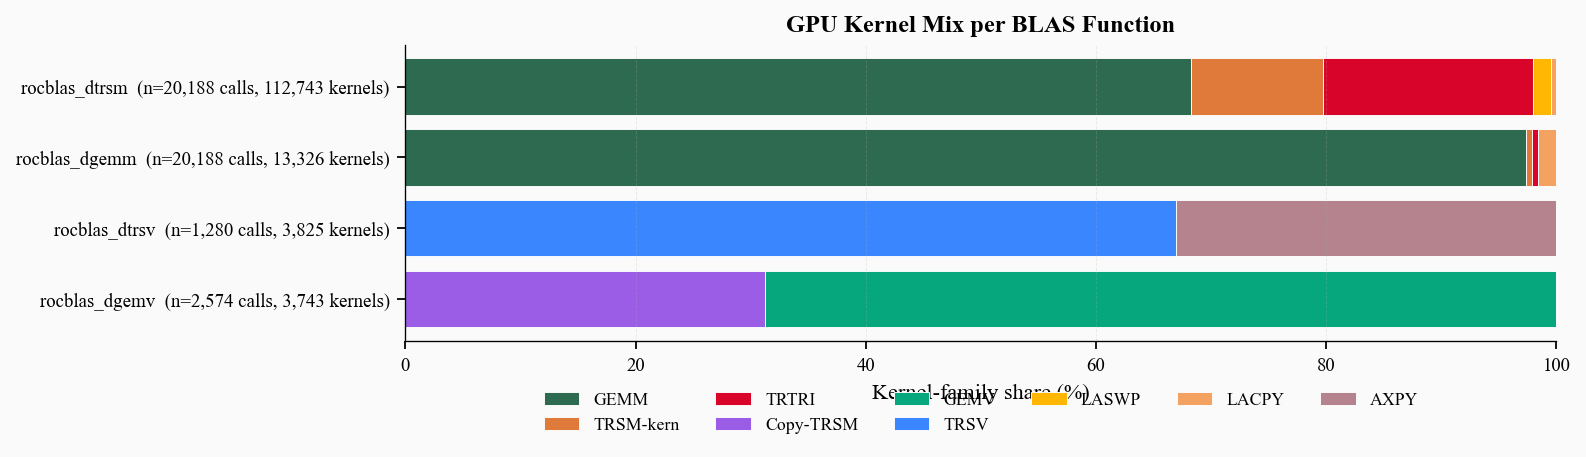

In [41]:
# -- Fig 1: family mix per BLAS call --
rows = []
for call, sub in corr.groupby('Call'):
    all_fams = [f for fs in sub['KernelFams'] for f in fs]
    if not all_fams: continue
    c = Counter(all_fams)
    total = sum(c.values())
    rows.append({'Call': call, 'TotalKernels': total, 'NumCalls': len(sub),
                 **{fam: 100*c.get(fam,0)/total for fam in FAMILY_PALETTE}})

if not rows:
    print("No kernels captured per BLAS call.")
else:
    mix = pd.DataFrame(rows).sort_values('TotalKernels', ascending=False).reset_index(drop=True)
    fams_present = [f for f in FAMILY_PALETTE if (mix[f] > 0.1).any()]

    fig, ax = plt.subplots(figsize=(10, max(3, 0.6*len(mix))), facecolor=BG)
    ax.set_facecolor(BG)
    left = np.zeros(len(mix))
    for fam in fams_present:
        vals = mix[fam].values
        ax.barh(range(len(mix)), vals, left=left,
                color=FAMILY_PALETTE[fam], label=fam,
                edgecolor='white', linewidth=0.4)
        left += vals

    ax.set_yticks(range(len(mix)))
    ax.set_yticklabels([f"{r.Call}  (n={r.NumCalls:,} calls, {r.TotalKernels:,} kernels)"
                        for r in mix.itertuples()], fontsize=8.5)
    ax.invert_yaxis()
    ax.set_xlabel('Kernel-family share (%)'); ax.set_xlim(0, 100)
    ax.set_title('GPU Kernel Mix per BLAS Function', fontweight='bold')
    ax.legend(ncol=min(6, len(fams_present)), frameon=False, fontsize=8,
              loc='upper center', bbox_to_anchor=(0.5, -0.12))
    ax.grid(axis='x', alpha=0.25, linestyle='--')
    fig.tight_layout()
    fig.savefig('kernlib_fig1_mix.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()

## Figure 2 — GEMM-variant breakdown inside rocblas_dgemm

HPL's DGEMM calls hit many different `Cijk_*_MT*` variants (tile sizes). Which ones dominate?

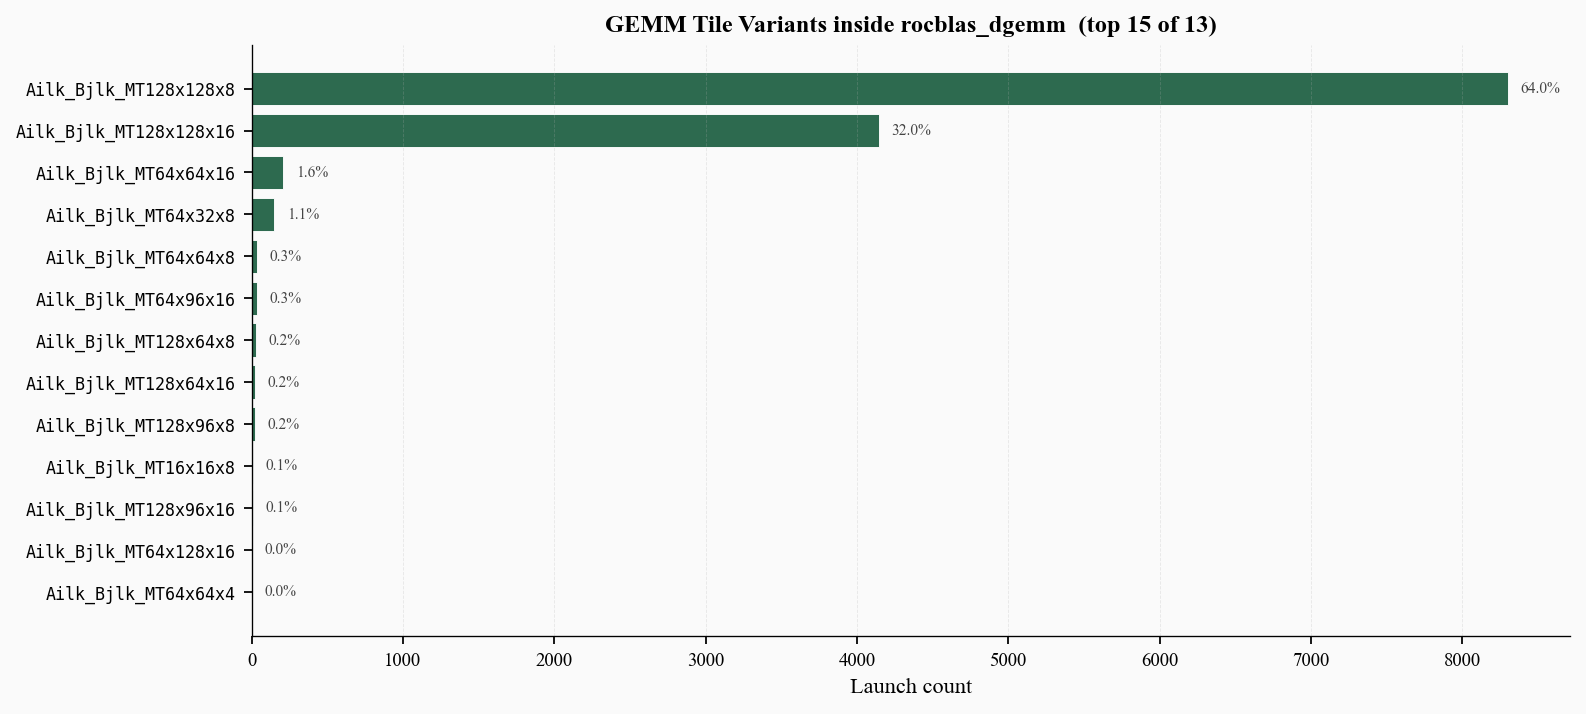

In [42]:
# -- Fig 2: GEMM-variant breakdown within rocblas_dgemm --
dgemm_rows = corr[corr['Call']=='rocblas_dgemm']
all_labels = [l for ls in dgemm_rows['KernelLabels'] for l in ls]
gemm_labels = [l for l in all_labels if l.startswith('Cijk_')]

if not gemm_labels:
    print("No GEMM kernels captured inside rocblas_dgemm windows.")
else:
    c = Counter(gemm_labels)
    top = c.most_common(15)
    labels = [t[0] for t in top]
    counts = [t[1] for t in top]

    fig, ax = plt.subplots(figsize=(10, max(4, 0.35*len(labels))), facecolor=BG)
    ax.set_facecolor(BG)
    ax.barh(range(len(labels)), counts, color='#2d6a4f',
            edgecolor='white', linewidth=0.4)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels([l.replace('Cijk_','') for l in labels], fontsize=7.5, family='monospace')
    ax.invert_yaxis()
    total = sum(c.values())
    for i, n in enumerate(counts):
        ax.text(n + max(counts)*0.01, i, f"{100*n/total:.1f}%",
                va='center', fontsize=7, color='#444')
    ax.set_xlabel('Launch count')
    ax.set_title(f'GEMM Tile Variants inside rocblas_dgemm  (top 15 of {len(c)})', fontweight='bold')
    ax.grid(axis='x', alpha=0.25, linestyle='--')
    fig.tight_layout()
    fig.savefig('kernlib_fig2_gemm_variants.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()

## Figure 3 — rocblas_dtrsm decomposition

rocblas_dtrsm launches a rich sequence of helper kernels: `rocblas_trtri_*`,
`rocblas_copy_matrix_trsm`, `rocblas_trsm_small_*`, plus the `Cijk_*` GEMMs it uses for block
updates. Here's the full label breakdown for trsm calls.

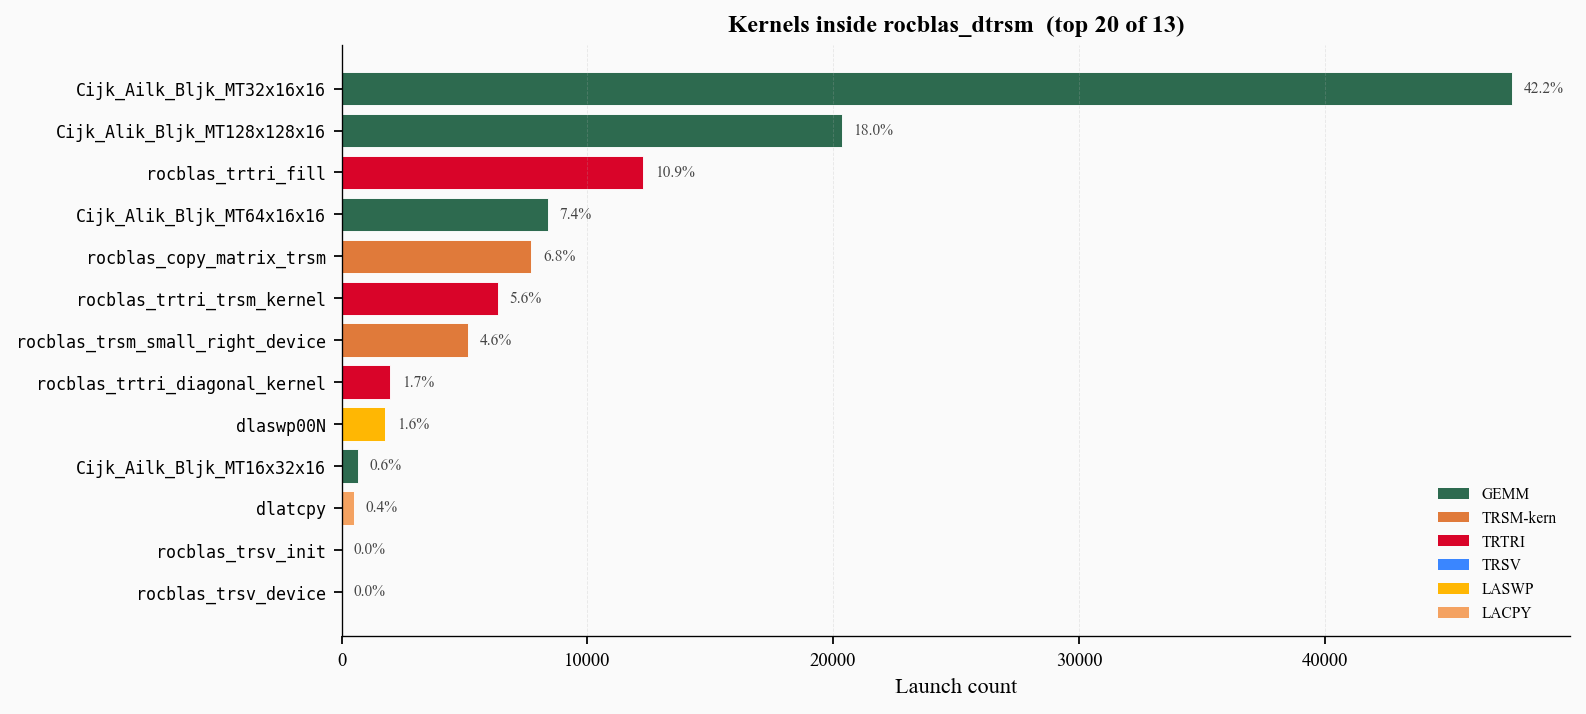

In [43]:
# -- Fig 3: kernel label breakdown inside rocblas_dtrsm --
dtrsm_rows = corr[corr['Call']=='rocblas_dtrsm']
all_labels = [l for ls in dtrsm_rows['KernelLabels'] for l in ls]

if not all_labels:
    print("No kernels captured inside rocblas_dtrsm windows.")
else:
    c = Counter(all_labels)
    top = c.most_common(20)
    labels = [t[0] for t in top]; counts = [t[1] for t in top]
    # colour by family
    def label_family(l): return gpu_family(l)
    colors = [FAMILY_PALETTE.get(label_family(l), '#999999') for l in labels]

    fig, ax = plt.subplots(figsize=(10, max(4, 0.35*len(labels))), facecolor=BG)
    ax.set_facecolor(BG)
    ax.barh(range(len(labels)), counts, color=colors,
            edgecolor='white', linewidth=0.4)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels, fontsize=7.5, family='monospace')
    ax.invert_yaxis()
    total = sum(c.values())
    for i, n in enumerate(counts):
        ax.text(n + max(counts)*0.01, i, f"{100*n/total:.1f}%",
                va='center', fontsize=7, color='#444')
    ax.set_xlabel('Launch count')
    ax.set_title(f'Kernels inside rocblas_dtrsm  (top 20 of {len(c)})', fontweight='bold')
    handles = [mpatches.Patch(facecolor=FAMILY_PALETTE[f], label=f)
               for f in FAMILY_PALETTE if f in [label_family(l) for l in labels]]
    ax.legend(handles=handles, frameon=False, fontsize=7, loc='lower right')
    ax.grid(axis='x', alpha=0.25, linestyle='--')
    fig.tight_layout()
    fig.savefig('kernlib_fig3_trsm_breakdown.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()

## Figure 4 — Power per BLAS call

Distribution of mean and peak power observed across each BLAS call type.

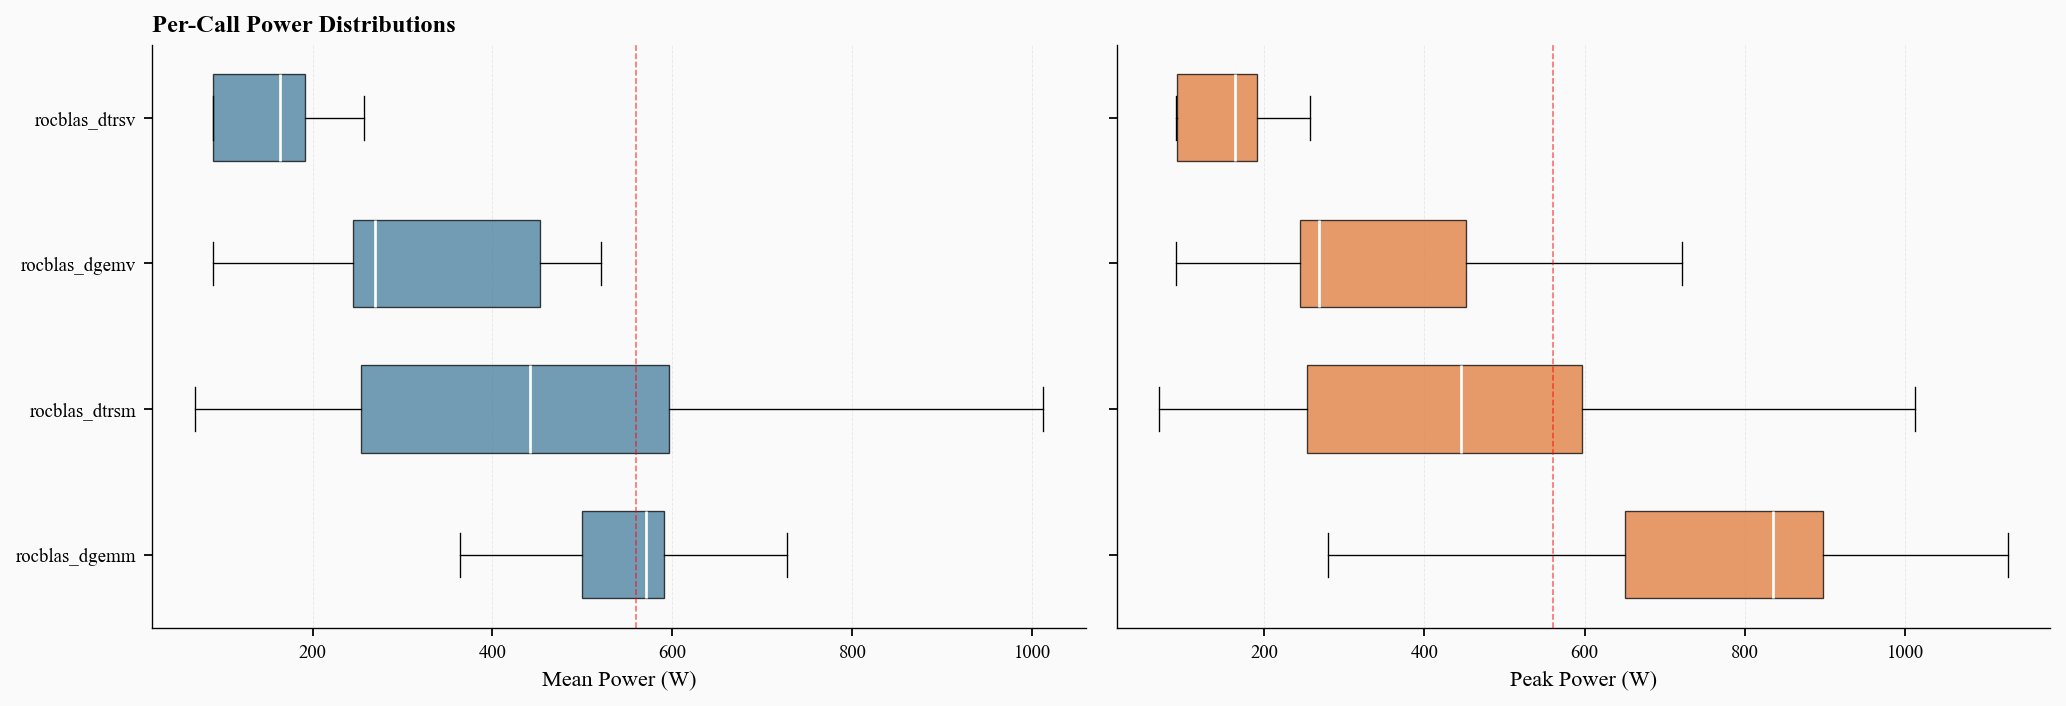

In [44]:
# -- Fig 4: power distributions per BLAS call --
plot_df = corr[corr['PowerSamples'] > 0].copy()

if plot_df.empty:
    print("No calls have power samples.")
else:
    order = plot_df.groupby('Call')['PowerMax'].median().sort_values(ascending=False).index.tolist()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor=BG, sharey=True)
    for ax, col, title in zip(axes,
                              ['PowerMean','PowerMax'],
                              ['Mean Power (W)','Peak Power (W)']):
        ax.set_facecolor(BG)
        data = [plot_df[plot_df['Call']==c][col].dropna().values for c in order]
        bp = ax.boxplot(data, positions=range(len(order)), widths=0.6, patch_artist=True,
                        showfliers=False, vert=False)
        for patch, c in zip(bp['boxes'], order):
            patch.set_facecolor('#457b9d' if col=='PowerMean' else '#e07a3a')
            patch.set_alpha(0.75); patch.set_edgecolor('black'); patch.set_linewidth(0.6)
        for el in ['whiskers','caps']:
            for line in bp[el]: line.set_color('black'); line.set_linewidth(0.6)
        for line in bp['medians']: line.set_color('white'); line.set_linewidth(1.2)
        ax.axvline(TDP_THRESHOLD, color='red', linestyle='--', linewidth=0.7, alpha=0.6)
        ax.set_yticks(range(len(order))); ax.set_yticklabels(order)
        ax.set_xlabel(title)
        ax.grid(axis='x', alpha=0.25, linestyle='--')
    axes[0].set_title('Per-Call Power Distributions', fontweight='bold', loc='left')
    fig.tight_layout()
    fig.savefig('kernlib_fig4_power_per_call.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()

## Figure 5 — Which GPU kernels coincide with the highest power?

Group by the first (dominant) GPU kernel label launched in each BLAS call and look at the
distribution of peak power observed.

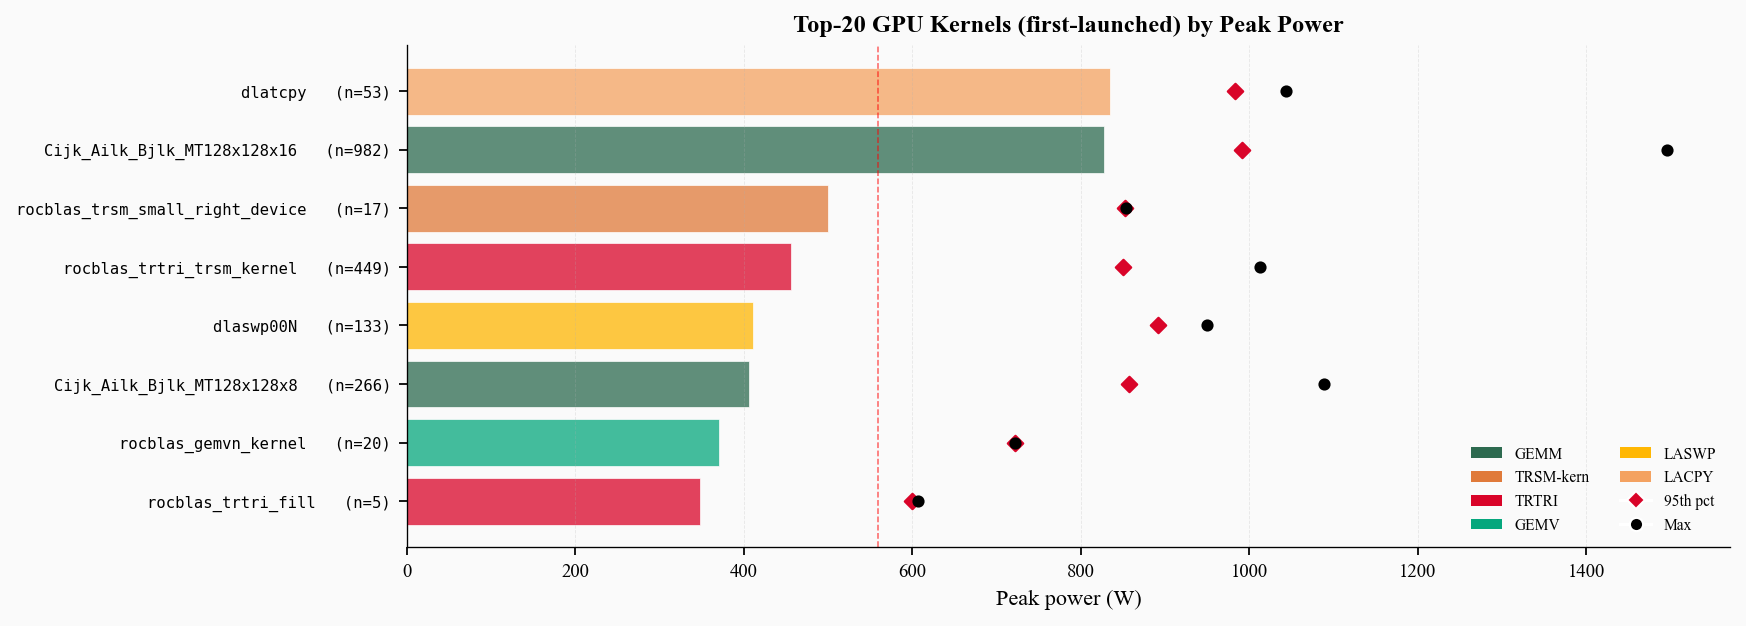

In [45]:
# -- Fig 5: peak power by dominant GPU kernel label --
with_kern = corr[(corr['FirstLabel'].notna()) & (corr['PowerSamples']>0)].copy()

if with_kern.empty:
    print("No data for kernel→power ranking.")
else:
    stats = (with_kern.groupby('FirstLabel')
             .agg(count=('PowerMax','size'),
                  mean_peak=('PowerMax','mean'),
                  p95_peak=('PowerMax', lambda s: np.percentile(s, 95)),
                  max_peak=('PowerMax','max'),
                  family=('FirstLabel', lambda s: gpu_family(s.iloc[0])))
             .reset_index())
    stats = stats[stats['count'] >= 5].sort_values('mean_peak', ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(11, max(4, 0.38*len(stats))), facecolor=BG)
    ax.set_facecolor(BG)
    colors = [FAMILY_PALETTE.get(f, '#999999') for f in stats['family']]
    y = np.arange(len(stats))
    ax.barh(y, stats['mean_peak'], color=colors, alpha=0.75,
            edgecolor='white', linewidth=0.4, label='Mean peak')
    ax.scatter(stats['p95_peak'], y, color='#d90429', s=24, marker='D',
               zorder=5, label='95th pct')
    ax.scatter(stats['max_peak'], y, color='black', s=20, marker='o',
               zorder=5, label='Max')
    ax.axvline(TDP_THRESHOLD, color='red', linestyle='--', linewidth=0.7, alpha=0.6)
    ax.set_yticks(y)
    ax.set_yticklabels([f"{lbl}   (n={cnt:,})"
                        for lbl, cnt in zip(stats['FirstLabel'], stats['count'])],
                        fontsize=7, family='monospace')
    ax.invert_yaxis()
    ax.set_xlabel('Peak power (W)')
    ax.set_title('Top-20 GPU Kernels (first-launched) by Peak Power', fontweight='bold')
    handles = [mpatches.Patch(facecolor=FAMILY_PALETTE[f], label=f)
               for f in FAMILY_PALETTE if f in stats['family'].values]
    ax.legend(handles=handles + [
        Line2D([0],[0], marker='D', color='w', markerfacecolor='#d90429', label='95th pct', markersize=6),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='black', label='Max', markersize=6),
    ], frameon=False, fontsize=7, loc='lower right', ncol=2)
    ax.grid(axis='x', alpha=0.25, linestyle='--')
    fig.tight_layout()
    fig.savefig('kernlib_fig5_kernel_power.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()

## Figure 6 — Timeline: BLAS calls, GPU kernels, and power

Pick one device and overlay the power curve with the GPU-kernel launch scatter (colored by
family) and Gantt-style bands for active CPU BLAS calls. First 20 s of GPU activity.

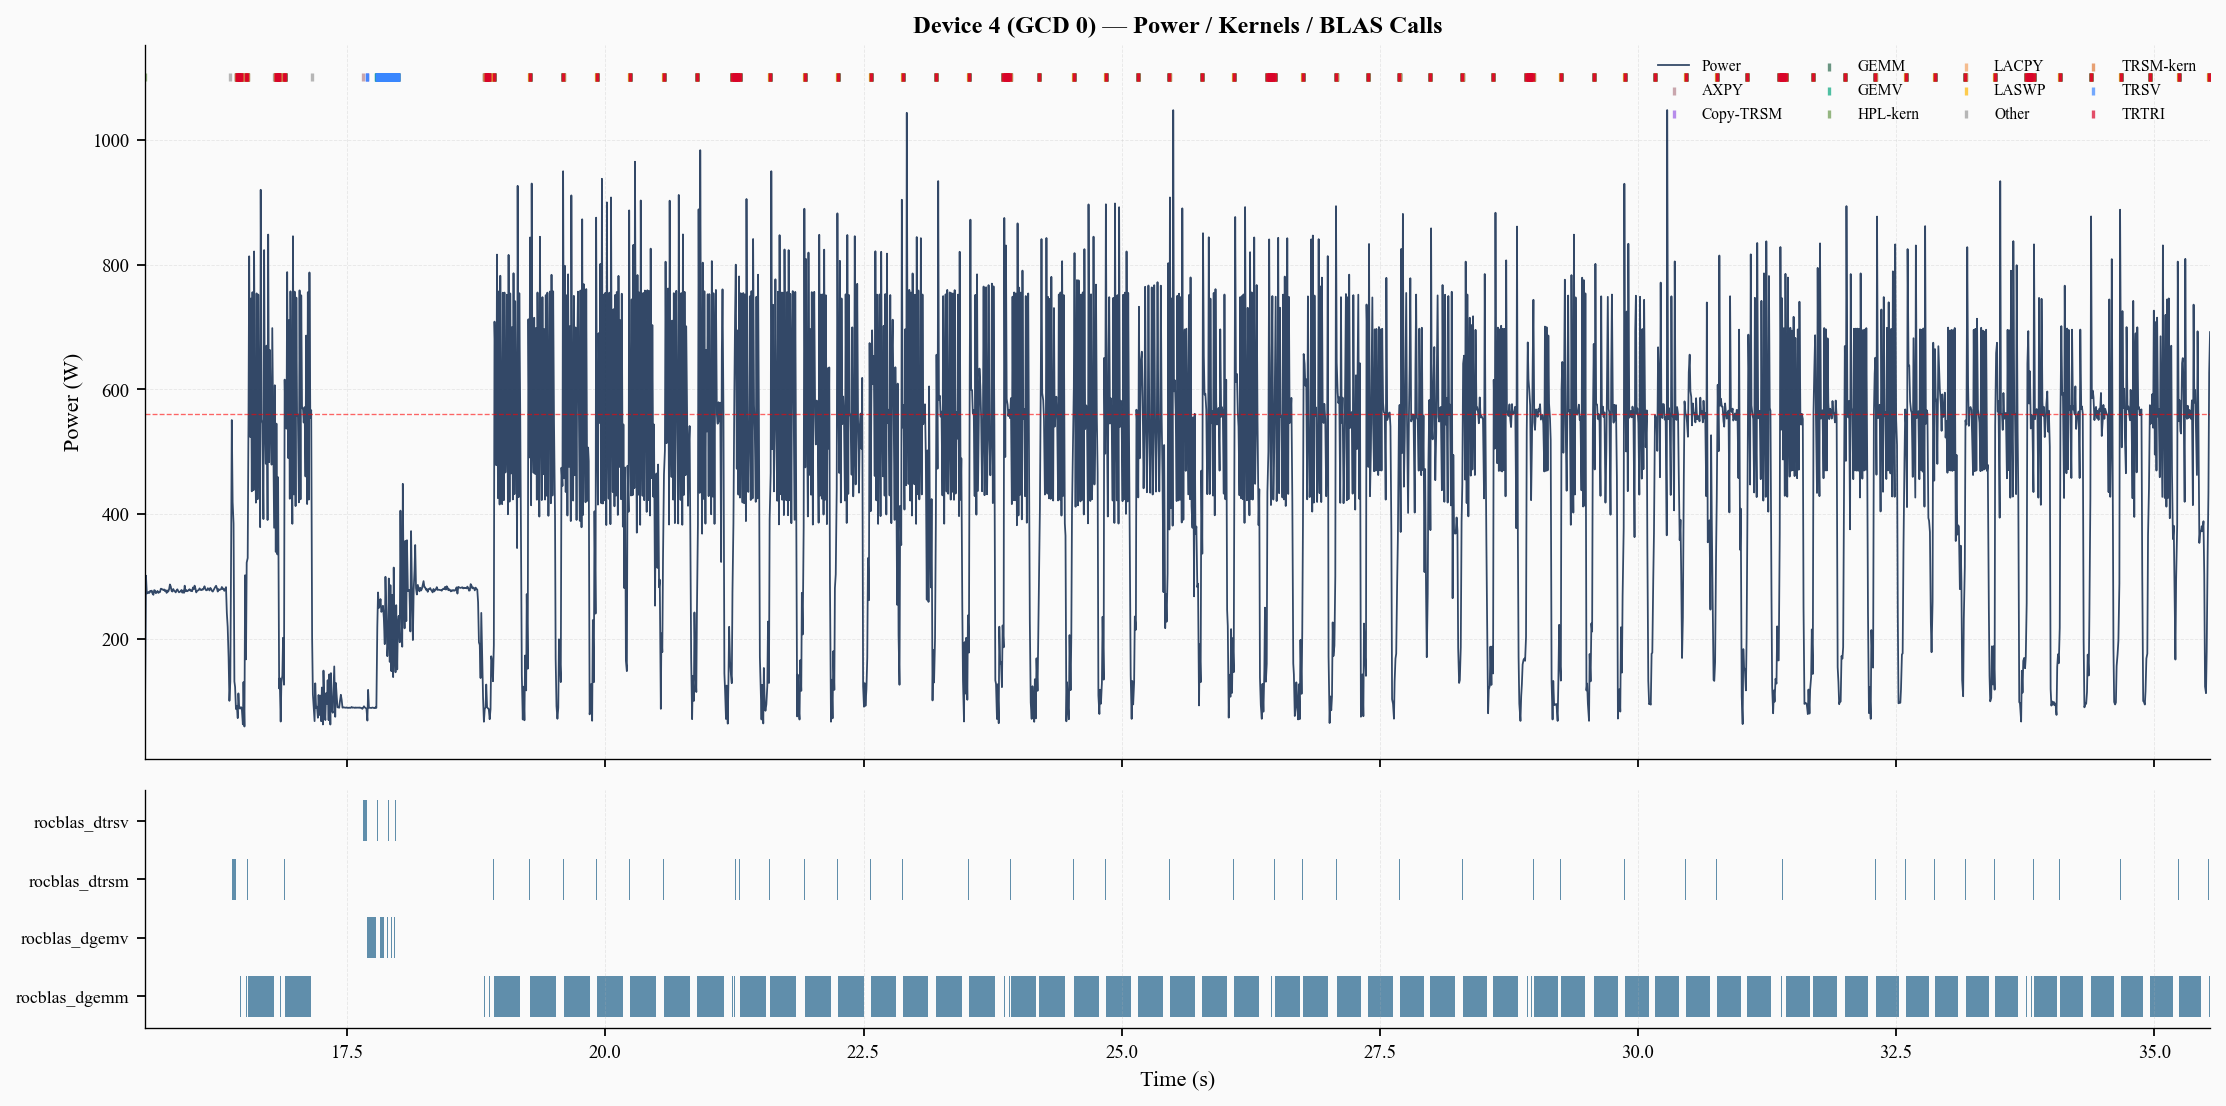

In [46]:
# -- Fig 6: power/kernel/BLAS timeline on one device --
DEV_FOCUS = 4   # MI250X device 4 → GCDs 0,1 → MPI Ranks 0,1
GCD_FOCUS = DEVICE_TO_GCDS[DEV_FOCUS][0]

pt, pv = power_traces.get(DEV_FOCUS, (np.array([]), np.array([])))
gpu_f = df_gpu[df_gpu['GCD']==GCD_FOCUS].copy()
cpu_f = df_cpu[df_cpu['Rank_ID']==GCD_FOCUS].sort_values('Start Time').reset_index(drop=True)

if len(gpu_f) == 0:
    print(f"No GPU kernels on GCD {GCD_FOCUS}")
else:
    t_start = gpu_f['Start Time'].min()
    t_end   = min(t_start + 20, gpu_f['End Time'].max())

    fig, axes = plt.subplots(2, 1, figsize=(14, 7),
                             gridspec_kw={'height_ratios':[3,1]},
                             sharex=True, facecolor=BG)
    for ax in axes: ax.set_facecolor(BG)

    # Power curve
    if len(pt):
        m = (pt >= t_start) & (pt <= t_end)
        axes[0].plot(pt[m], pv[m], color='#1d3557', linewidth=0.8, alpha=0.9, label='Power')
    axes[0].axhline(TDP_THRESHOLD, color='red', linestyle='--', linewidth=0.6, alpha=0.6)
    axes[0].set_ylabel('Power (W)')
    axes[0].grid(alpha=0.25, linestyle='--')
    axes[0].set_title(f'Device {DEV_FOCUS} (GCD {GCD_FOCUS}) — Power / Kernels / BLAS Calls',
                       fontweight='bold')

    # Kernel scatter (by family)
    kslice = gpu_f[(gpu_f['Start Time']>=t_start) & (gpu_f['End Time']<=t_end)]
    yk = axes[0].get_ylim()[1] if len(pt)==0 else max(pv[m].max() if m.any() else 0, TDP_THRESHOLD) * 1.05
    for fam, sub in kslice.groupby('Family'):
        axes[0].scatter(sub['Start Time'], [yk]*len(sub),
                        c=FAMILY_PALETTE.get(fam, '#999'), s=10, marker='|',
                        alpha=0.7, label=fam)

    # BLAS call bands
    cslice = cpu_f[(cpu_f['Start Time']<t_end) & (cpu_f['End Time']>t_start)]
    unique_calls = sorted(cslice['Short'].unique())
    y_positions = {c: i for i, c in enumerate(unique_calls)}
    for _, r in cslice.iterrows():
        y = y_positions[r['Short']]
        s = max(r['Start Time'], t_start); e = min(r['End Time'], t_end)
        axes[1].barh(y, e-s, left=s, height=0.7,
                     color='#457b9d', edgecolor='none', alpha=0.85)
    axes[1].set_yticks(list(y_positions.values()))
    axes[1].set_yticklabels(list(y_positions.keys()), fontsize=8)
    axes[1].set_xlabel('Time (s)')
    axes[1].set_xlim(t_start, t_end)
    axes[1].grid(axis='x', alpha=0.25, linestyle='--')

    axes[0].legend(frameon=False, fontsize=7, ncol=4, loc='upper right')
    fig.tight_layout()
    fig.savefig('kernlib_fig6_timeline.pdf', facecolor=BG, bbox_inches='tight')
    plt.show()

## Figure 7 — Repeating call sequences that drive spikes

Slide a window of size 3 over each rank's BLAS call stream (e.g. `dgemm → dtrsm → dgemm`) and
rank the 3-grams by the mean peak power observed over the triplet.

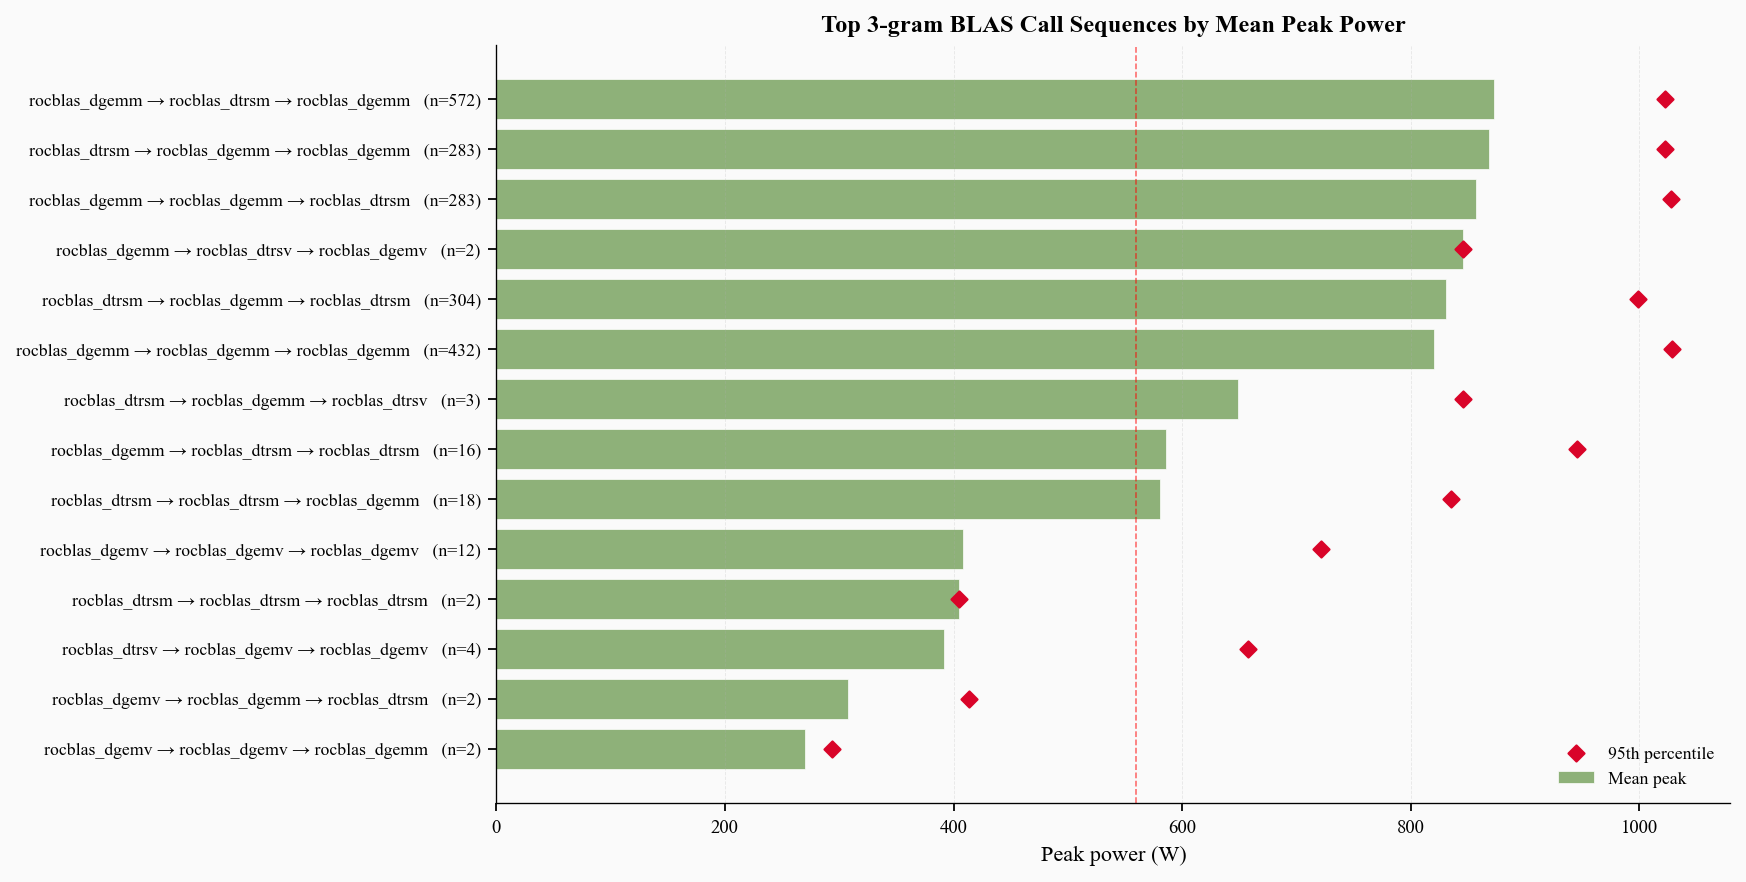

In [49]:
# -- Fig 7: 3-gram CPU call sequences ranked by mean peak power --
N = 3
co = corr[corr['PowerSamples']>0].sort_values(['Rank','Start']).reset_index(drop=True)

ngrams = []
for rid, sub in co.groupby('Rank'):
    calls = sub['Call'].tolist()
    peaks = sub['PowerMax'].tolist()
    for i in range(len(calls)-N+1):
        ngrams.append({'ngram': ' → '.join(calls[i:i+N]),
                       'peak': max(peaks[i:i+N])})

if not ngrams:
    print("No n-gram data.")
else:
    nd = pd.DataFrame(ngrams)
    st = (nd.groupby('ngram')
          .agg(count=('peak','size'),
               mean_peak=('peak','mean'),
               p95_peak=('peak', lambda s: np.percentile(s, 95)),
               max_peak=('peak','max'))
          .reset_index())
    st = st[st['count'] >= max(2, int(st['count'].median()))]
    st = st.sort_values('mean_peak', ascending=False).head(15)

    if st.empty:
        print("Not enough n-gram data after filtering.")
    else:
        fig, ax = plt.subplots(figsize=(11, max(4, 0.4*len(st))), facecolor=BG)
        ax.set_facecolor(BG)
        y = np.arange(len(st))
        ax.barh(y, st['mean_peak'], color='#6a994e', alpha=0.75,
                edgecolor='white', linewidth=0.4, label='Mean peak')
        ax.scatter(st['p95_peak'], y, color='#d90429', s=26, marker='D',
                   zorder=5, label='95th percentile')
        ax.axvline(TDP_THRESHOLD, color='red', linestyle='--', linewidth=0.7, alpha=0.6)
        ax.set_yticks(y)
        ax.set_yticklabels([f"{g}   (n={c:,})" for g, c in zip(st['ngram'], st['count'])],
                            fontsize=8)
        ax.invert_yaxis()
        ax.set_xlabel('Peak power (W)')
        ax.set_title(f'Top {N}-gram BLAS Call Sequences by Mean Peak Power', fontweight='bold')
        ax.legend(frameon=False, fontsize=8)
        ax.grid(axis='x', alpha=0.25, linestyle='--')
        fig.tight_layout()
        fig.savefig('kernlib_fig7_ngrams.pdf', facecolor=BG, bbox_inches='tight')
        plt.show()

## Summary

In [ ]:
# -- Summary table: one row per BLAS function --
if corr.empty:
    print("No correlated data.")
else:
    summary = (corr[corr['PowerSamples']>0]
               .groupby('Call')
               .agg(invocations=('Call','size'),
                    avg_kernels=('NumKernels','mean'),
                    mean_peak_W=('PowerMax','mean'),
                    p95_peak_W=('PowerMax', lambda s: np.percentile(s, 95)),
                    max_peak_W=('PowerMax','max'),
                    mean_duration_ms=('Duration', lambda s: 1000*s.mean()))
               .round(2)
               .sort_values('mean_peak_W', ascending=False))
    print(summary.to_string())

               invocations  avg_kernels  mean_peak_W  p95_peak_W  max_peak_W  mean_duration_ms
Call                                                                                          
rocblas_dgemm         1307         1.04       740.42      984.33     1496.34             85.47
rocblas_dtrsm          611        13.73       448.73      861.82     1012.34              3.74
rocblas_dgemv           22         1.09       347.01      718.23      721.69             10.98
rocblas_dtrsv            5         2.60       158.59      243.63      256.69             10.81
